<a href="https://colab.research.google.com/github/ShlokVaibhav/DSP/blob/main/DSSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BPSK modulation and demodulation implemented

BPSK_mod_gen function generates the BPSK modulated carrier wave on the time-grid, the phase added is either 0 or $\pi$

## AI Usage: LLms consulted for suggestions for python syntax only

# 1. BPSK generation

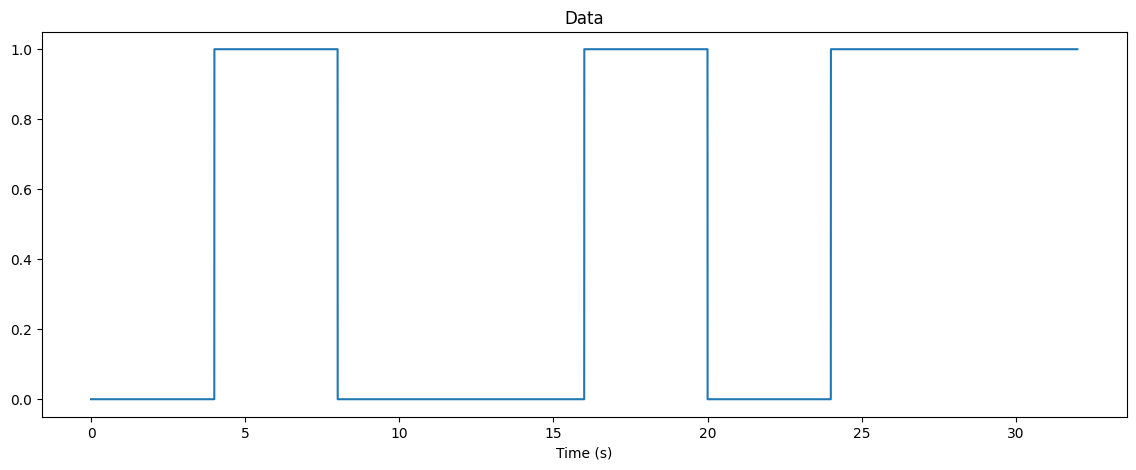

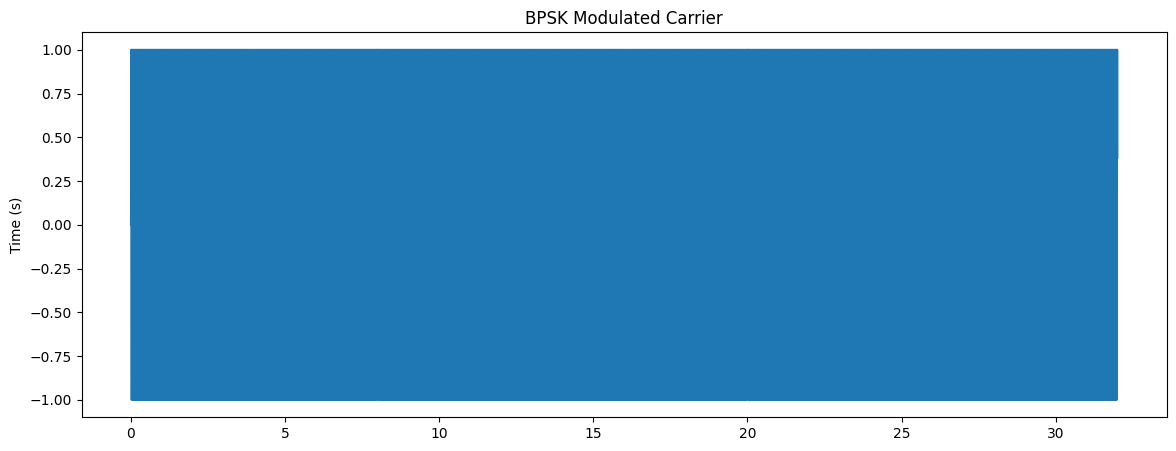

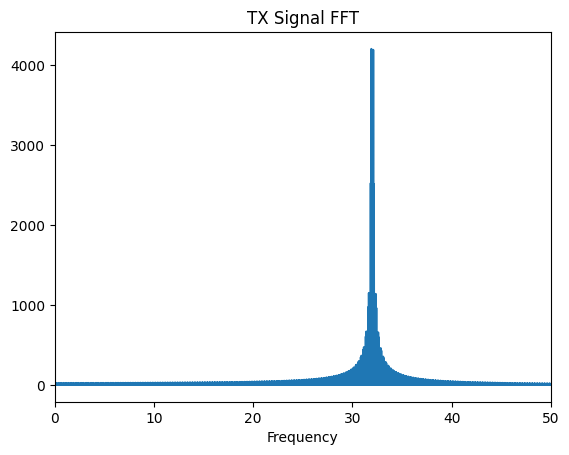

In [10]:
import sys
import numpy as np
import matplotlib.pyplot as plt


Fc = 32 # Carrier Rate
Fsym = 0.25    # Symbol Rate
t_start = 0
Fs = 512   # Sample frequency (and 1/time step)
dt = 1/Fs  # Time step
Data = np.array([0, 1, 0, 0, 1, 0, 1, 1])      # Data to be transmitted
t_stop = len(Data)/Fsym        # Stop time of sim based on Data and symbol rate
t = np.arange(0, t_stop, dt)   # time grid

def FFT_gen(x, Fs, title_str = "", Fs_plot_cutoff = None):
    # This function plots the fft of signal, i have ignored fftshift and used the basic working version from llm and docs
    if Fs_plot_cutoff is None:
        Fs_plot_cutoff = Fs
    x_w = np.fft.fft(x)
    N = len(x)
    freqs = np.fft.fftfreq(N, d=1/Fs)
    plt.plot(freqs, np.abs(x_w))
    plt.xlim([0, Fs_plot_cutoff])
    plt.xlabel("Frequency")
    plt.title(title_str)
    plt.show()


def BPSK_mod_gen(Data, Fsym, Fs, Fc, t, plot_en=1):
    # This function generates the BSPK modulated waveform to be transmitted
    Phase = np.pi*np.repeat(Data, np.round(Fs/Fsym))  # BPSK Phase based on data, either 0 or pi
    Carrier = np.sin(2*np.pi*Fc*t+Phase)            # Carrier Wave
    #print(t.size)
    #print(Phase.size)
    if plot_en==1:
        plt.figure(figsize=(14, 5))
        plt.plot(t, Phase/np.pi)
        plt.title("Data")
        plt.xlabel("Time (s)")
        plt.show()
        plt.figure(figsize=(14, 5))
        plt.plot(t, Carrier)
        plt.title("BPSK Modulated Carrier")
        plt.ylabel("Time (s)")
        plt.show()
    return Carrier

TX_Signal = BPSK_mod_gen(Data, Fsym, Fs, Fc, t)
FFT_gen(TX_Signal, Fs, "TX Signal FFT", 50)

# 2. Channel Propagation Stage
I am Debugging why the noise FFT feels wrong with regards to axes wrapping

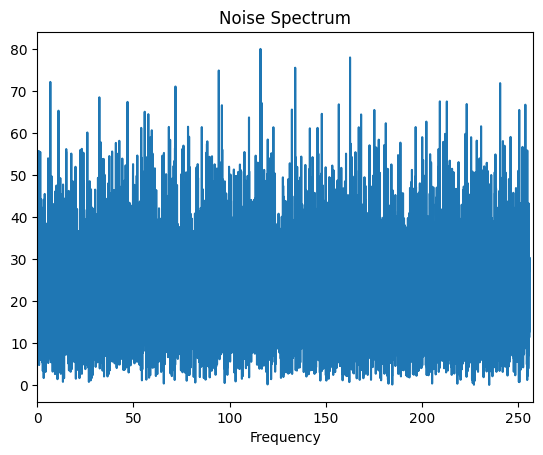

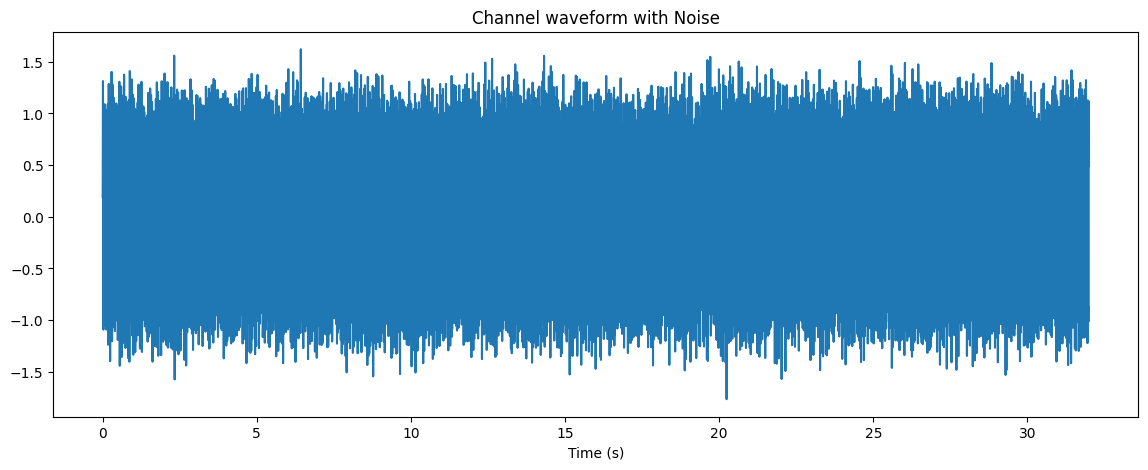

In [23]:
def Channel_Transmit(Carrier, Fs, plot_en=1):
    Noise = 0.2*np.random.normal(0, 1, size = Carrier.shape)      # Prove that this is AWGN
    FFT_gen(Noise, Fs, "Noise Spectrum", 258)
    Channel_Signal = Carrier+Noise     # Adding noise to the transmitted signal
    if plot_en==1:
        plt.figure(figsize=(14, 5))
        plt.plot(t, Channel_Signal)
        plt.title("Channel waveform with Noise")
        plt.xlabel("Time (s)")

    return Channel_Signal

Channel_Signal =  Channel_Transmit(TX_Signal, Fs)
plt.show()


# 3. RX demodulation stage

Recieved Signal ------> Local Oscillator ------> Envelope Detection ------> ADC -----> Recovered Data

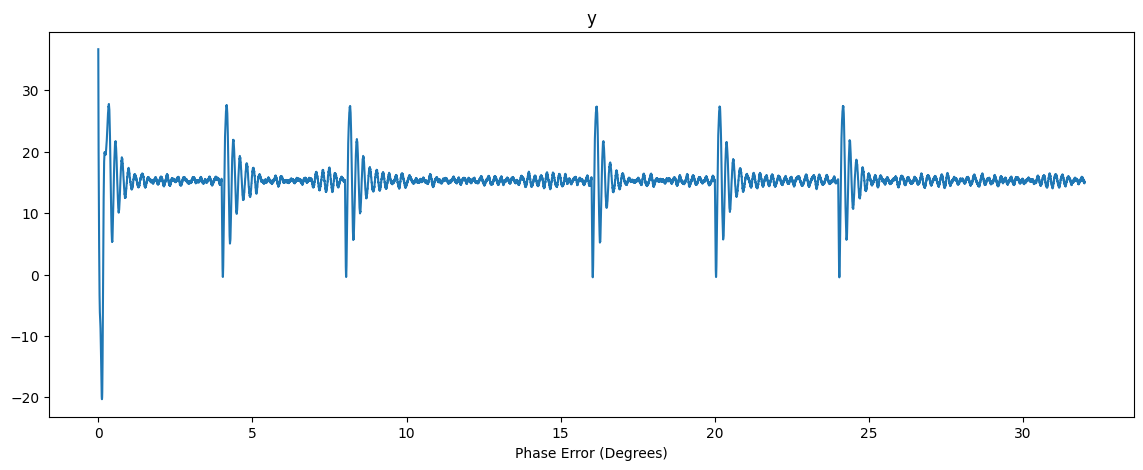

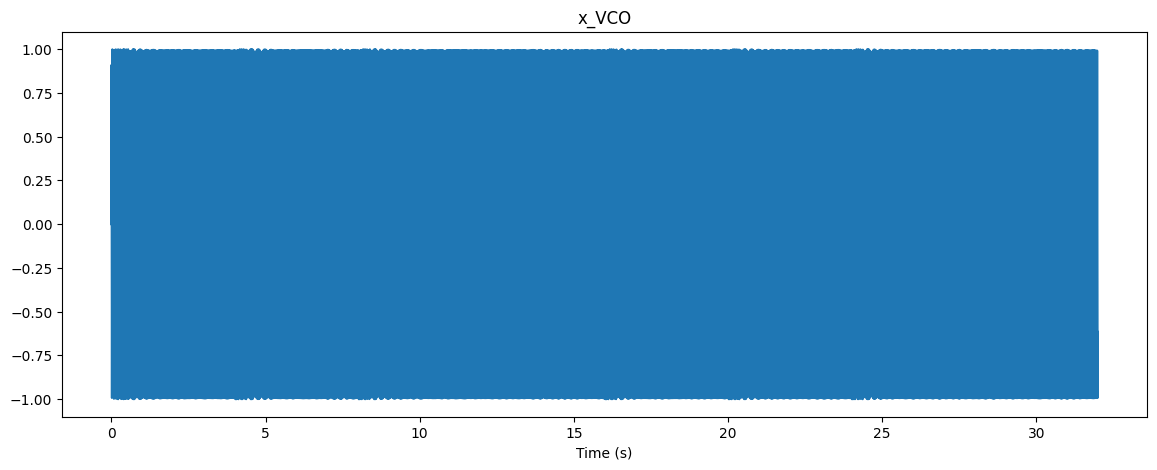

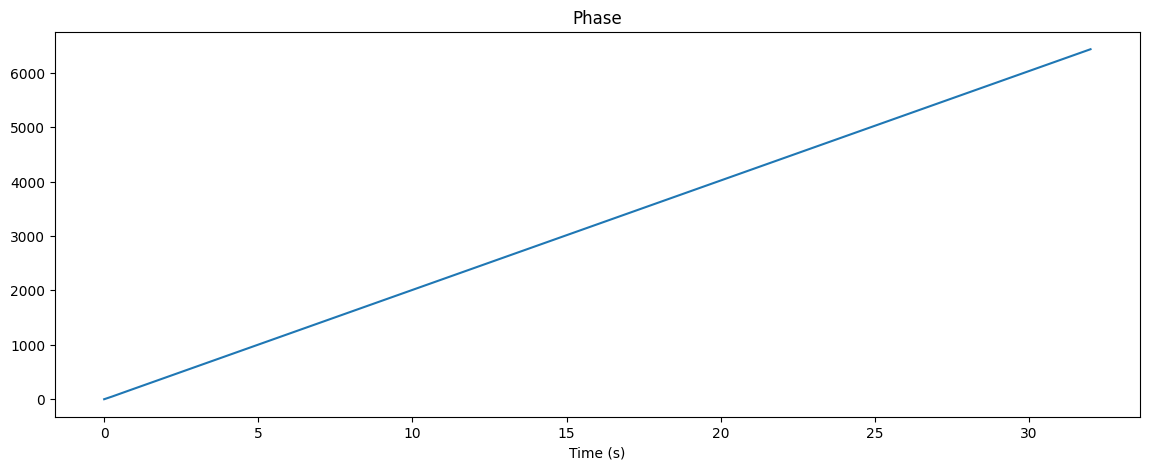

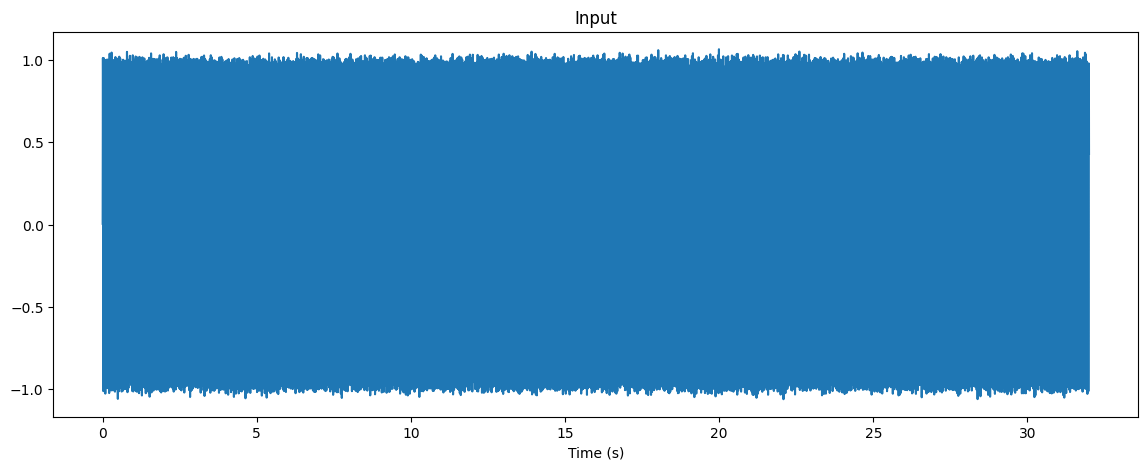

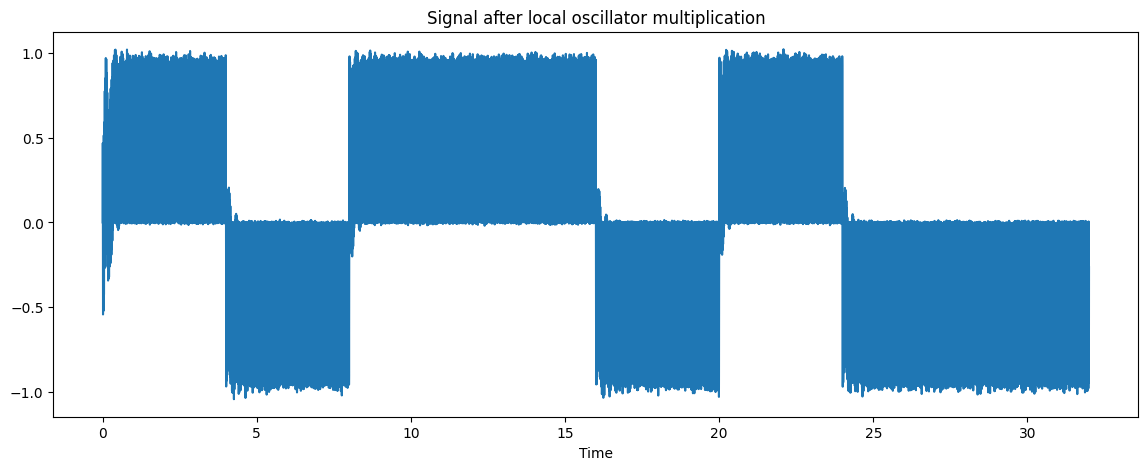

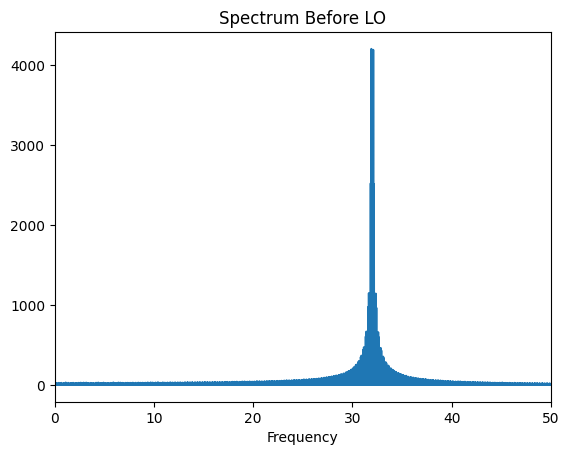

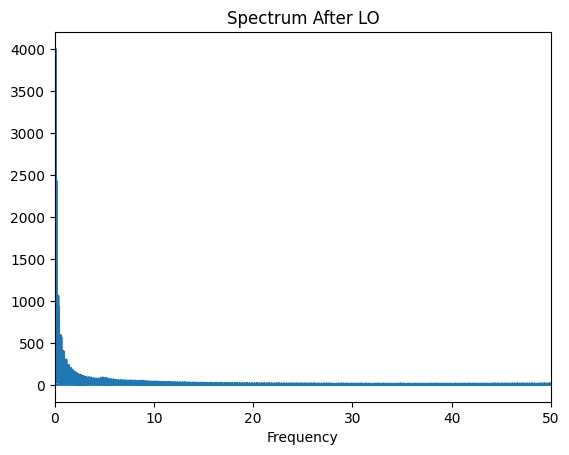

In [21]:
def VCO(K, dt, phi_0, f, F0):
    phi = phi_0+2*np.pi*(F0+K*f)*dt
    return (phi)

def Mixer(f1, f2):
    return f1*f2

def LPF_Costas(x, y0, dt, f_C):
    # Forward Euler based LPF after the envelope detector to remove noise
    RC = 1/(f_C*2*np.pi)
    y = y0+(x-y0)/RC*dt
    return y


def Costas(x, Fc, Error, time):
    x_lo = np.zeros(x.shape)
    x_lo_sin = np.zeros(x.shape)
    
    x_VCO = np.zeros(x.shape)
    x_VCO_sin = np.zeros(x.shape)
    phi_VCO = np.zeros(x.shape)
    y = np.zeros(x.shape)
    y1 = np.zeros(x.shape)
    y2 = np.zeros(x.shape)
    ys = np.ones(x.shape)
    y1s = np.zeros(x.shape)
    y2s = np.zeros(x.shape)
    
    y[0] = 0.4
    y1[0] = 0.4
    y2[0] = 0.4
    ys[0] = 0.4
    y1s[0] = 0.4
    y1s[0] = 0.4
    
    PLL = 0
    if PLL==1: # We are implementing PLL
        for ind in range(1, len(y)):
            phi_VCO[ind] = VCO(10, dt, phi_VCO[ind-1], y[ind-1], Fc-Error)
            x_VCO[ind] = np.cos(phi_VCO[ind])
            x_lo[ind] = x_VCO[ind]*x[ind]
            y1[ind] = LPF_Costas(x_lo[ind], y1[ind-1], dt, 6)
            y2[ind] = LPF_Costas(y1[ind], y2[ind-1], dt, 9)
            y[ind] = LPF_Costas(y2[ind], y[ind-1], dt, 12)
        plt.figure(figsize=(14, 5))
        plt.plot(time, y)
        plt.title("y")
        plt.xlabel("Time (s)")
        plt.show()
    
    else: # We are implementing Costas Loop
        for ind in range(1, len(y)):
            phi_VCO[ind] = VCO(30, dt, phi_VCO[ind-1], y[ind-1]*ys[ind-1], Fc-Error)
            x_VCO[ind] = np.cos(phi_VCO[ind])
            x_VCO_sin[ind] = -np.sin(phi_VCO[ind])
            x_lo[ind] = x_VCO[ind]*x[ind]
            x_lo_sin[ind] = x_VCO_sin[ind]*x[ind]
            y1[ind] = LPF_Costas(x_lo[ind], y1[ind-1], dt, 6)
            y2[ind] = LPF_Costas(y1[ind], y2[ind-1], dt, 9)
            y[ind] = LPF_Costas(y2[ind], y[ind-1], dt, 12)
            y1s[ind] = LPF_Costas(x_lo_sin[ind], y1s[ind-1], dt, 6)
            y2s[ind] = LPF_Costas(y1s[ind], y2s[ind-1], dt, 9)
            ys[ind] = LPF_Costas(y2s[ind], ys[ind-1], dt, 12)
    plt.figure(figsize=(14, 5))
    plt.plot(time, 4*180/np.pi*y*ys)
    plt.title("y")
    plt.xlabel("Phase Error (Degrees)")
    plt.show()   
    
    plt.figure(figsize=(14, 5))
    plt.plot(time, x_VCO)
    plt.title("x_VCO")
    plt.xlabel("Time (s)")
    plt.show()
    
    plt.figure(figsize=(14, 5))
    plt.plot(time, phi_VCO)
    plt.title("Phase")
    plt.xlabel("Time (s)")
    plt.show()
    
    plt.figure(figsize=(14, 5))
    plt.plot(time, x)
    plt.title("Input")
    plt.xlabel("Time (s)")
    plt.show()
    return x_VCO
    


def RX_Demod(Carrier, Fc, t):
    # This function multiplies the received signal with a pure carrier wave, for now Costas loop is assumed
    Local_Carrier = Costas(Carrier, Fc, 2, t)           # Assumed given somehow
    Recovered_Signal = Carrier*Local_Carrier
    plt.figure(figsize=(14, 5))
    plt.plot(t, Recovered_Signal)
    plt.xlabel("Time")
    plt.title("Signal after local oscillator multiplication")
    plt.show()
    return Recovered_Signal

def Envelope(x, Fs):
    # Forward Euler based envelope detector
    RC = 0.1
    y = np.zeros(x.shape)
    for ind in range(1, x.shape[0]):
        if x[ind]>y[ind-1]:
            y[ind] = x[ind]  # The diode conducts
        else:
            y[ind] = y[ind-1]-y[ind-1]/RC/Fs      # forward Euler Differential equation
        #if ind> 206 and ind <210:
            #print(str(x[ind]) + " and "+ str(x[ind-1]))
            #print(str(y[ind]) + " and "+ str(y[ind-1]))
    return y

def LPF(x, Fs):
    # Forward Euler based LPF after the envelope detector to remove noise
    RC = 0.05
    y = np.zeros(x.shape)
    for ind in range(1, x.shape[0]):
        y[ind] = y[ind-1]+(x[ind]-y[ind-1])/RC/Fs
    return y

def Single_Bit_ADC(Data_wave, t, Fsym):
    # Compares the signal to a single threshold
    count = 1/2
    Datum = np.zeros(Data_wave.shape)
    while 1/Fsym*count < np.max(t):
        time_index = np.where(t>1/Fsym*count)[0][0]     #The first sample near the sampling event determined by the count function
        sample = Data_wave[time_index]
        comparator = sample<0.5
        Datum[time_index:] = (comparator)
        count = count+1

    return Datum

# Local oscillator multiplication
RX_Demodulated_Signal = RX_Demod(Channel_Signal, Fc, t)
# Data envelope generation
Data_Envelope = Envelope(RX_Demodulated_Signal, Fs)
# Further Low pass filtering
Data_LPF = LPF(Data_Envelope, Fs)
# ADC Stage
Data_raw = Single_Bit_ADC(Data_LPF, t, Fsym)


FFT_gen(Channel_Signal, Fs, "Spectrum Before LO", 50)
FFT_gen(RX_Demodulated_Signal, Fs, "Spectrum After LO", 50)


Can see the Envelope and the ADC outputs match the originally transmitted signal

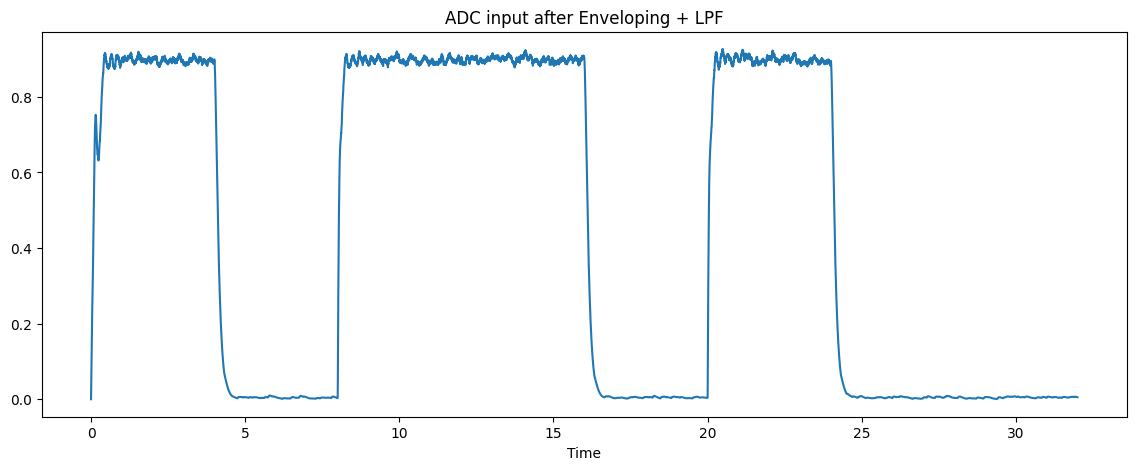

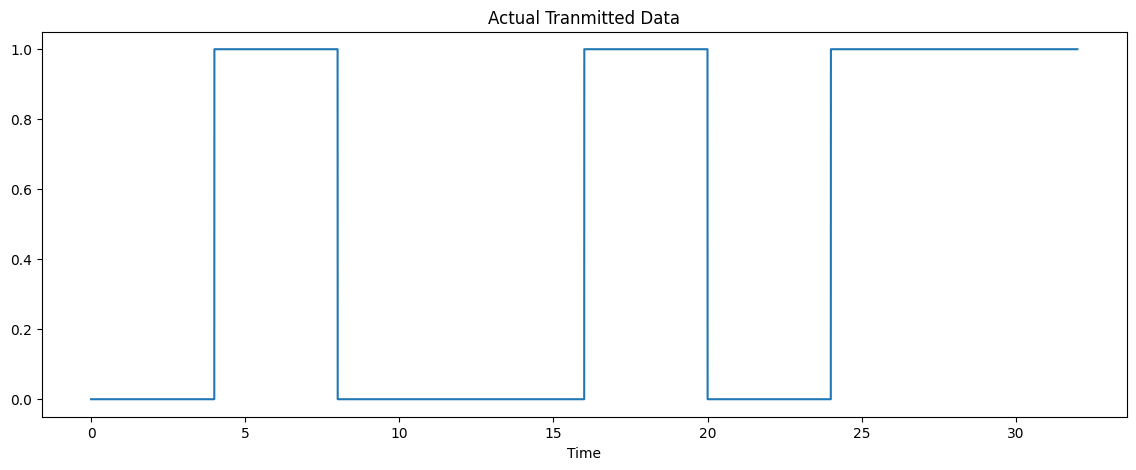

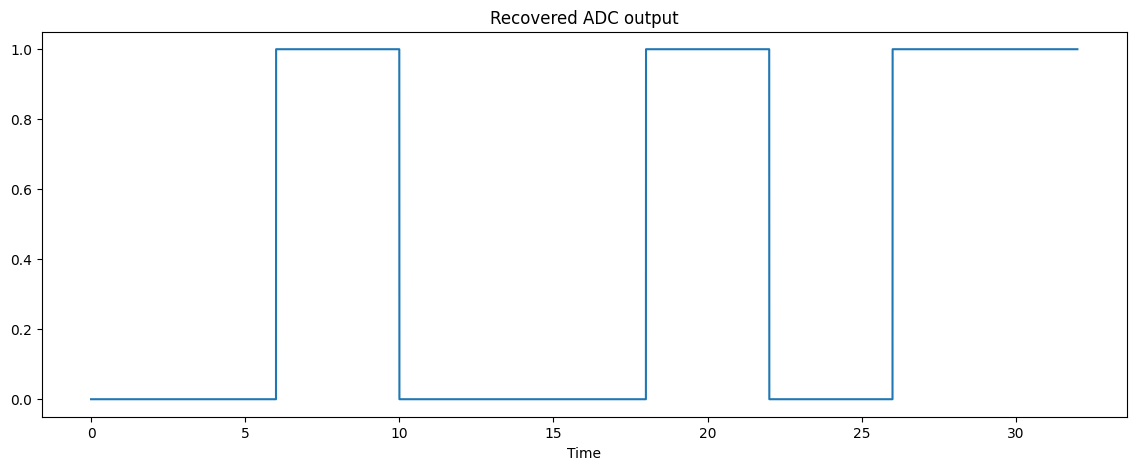

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(t, Data_LPF)
plt.xlabel("Time")
plt.title("ADC input after Enveloping + LPF")
plt.show()



plt.figure(figsize=(14, 5))
plt.plot(t, np.repeat(Data, np.round(Fs/Fsym)))
plt.xlabel("Time")
plt.title("Actual Tranmitted Data")
plt.show()
plt.figure(figsize=(14, 5))
plt.plot(t, Data_raw)
plt.xlabel("Time")
plt.title("Recovered ADC output")
plt.show()


